# Random Signal

- Jose Gonzalez Lopez

- Mykola Liashuha

# Imports

In [1]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np
import cv2 #Read images and do operations
#import random

#WE NEED TOOLBOX ZIP IN NUMERICAL TOURS (DO NOT TOUCH THIS CHUNK!!!!!)
from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
%load_ext autoreload
%autoreload 2
%pylab inline
%matplotlib inline


from scipy.io import wavfile #Read wavfiles
from scipy.signal import periodogram,welch #Get periodograms
from scipy.fft import fft, ifft,fftfreq #Fourier transform


SyntaxError: import * only allowed at module level (<ipython-input-1-a38ac9dc6011>, line 2)

# Auxiliar functions

In [2]:
#Code

# Introduction
This is the intro

# 1. Noise analysis
In this section we will analyse the noise files given for this exercise

## Noise 1 

To see that the data file are noises, let's just do a little experiment by ploting the fourier transform of the noise and see what happens.

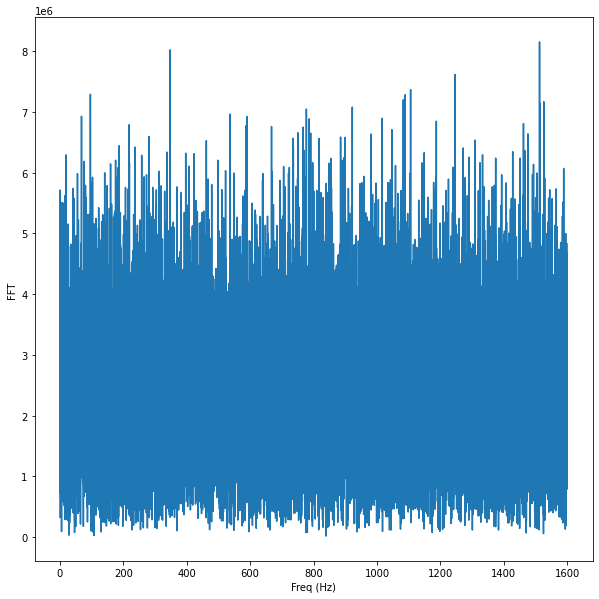

In [79]:
samplerate_1, data_1 = wavfile.read("noise1.wav") #Read the file
N = data_1.shape[0]
# sample spacing
T = 1.0 / samplerate_1
#Transform
yf = fft(data_1)
xf = fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

In the image above, the fourier transform cannot tell us any infomation about the signal because its plot is a total mess. This means that we are dealing with noise, a random signal. So, to actually analyse this data, we have to get its power spectrum

### Periodogram

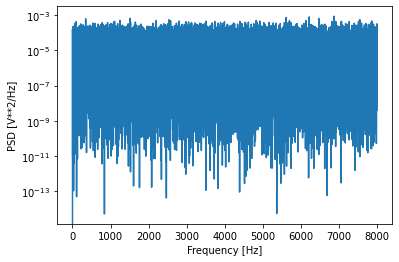

In [33]:
f, Pxx_den = periodogram(data_1, samplerate_1)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([1e-7, 1e2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

### Welsh method

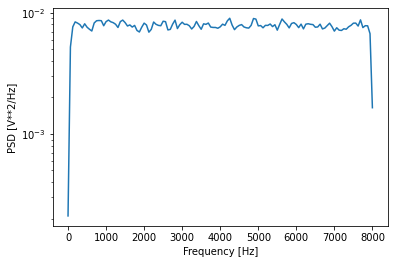

In [32]:
f, Pxx_den = welch(data_1, samplerate_1)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([0.5e-3, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

### Color identification

In [ ]:
#Code

## Noise 2

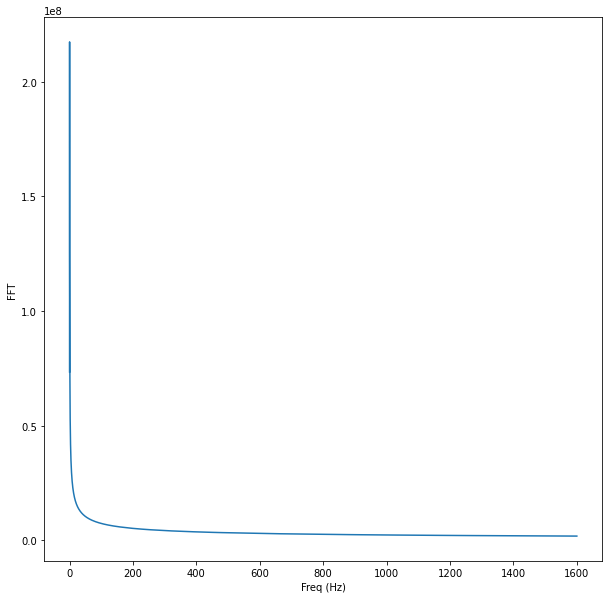

In [21]:
samplerate_2, data_2 = wavfile.read("noise2.wav") #Read the file
N = data_2.shape[0]
# sample spacing
T = 1.0 / samplerate_2
#Transform
yf = fft(data_2)
xf= fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

### Periodogram

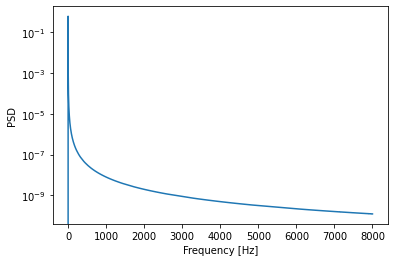

In [23]:
f, Pxx_den = periodogram(data_2, samplerate_2)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([1e-7, 1e2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD')
plt.show()

### Welsh method

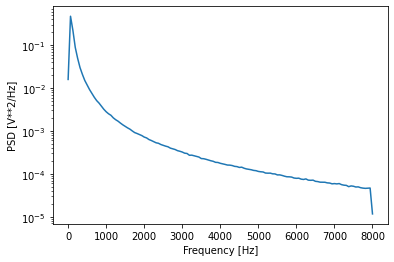

In [25]:
f, Pxx_den = welch(data_2, samplerate_2)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([0.5e-3, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

### Color identification

In [ ]:
#Code

## Noise 3

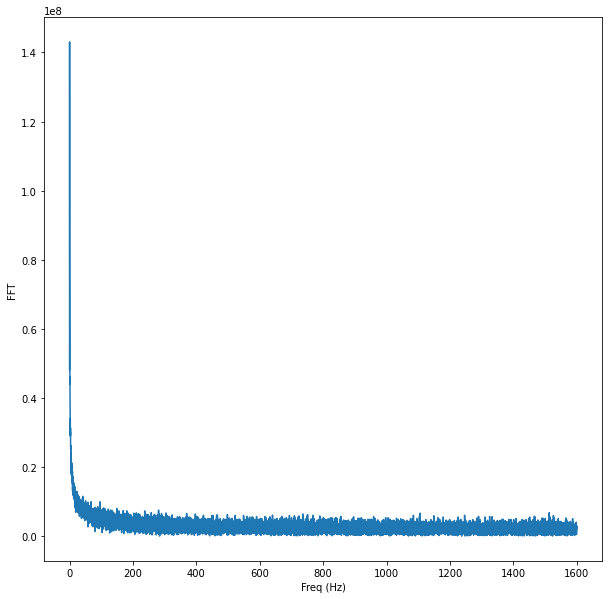

In [27]:
samplerate_3, data_3 = wavfile.read("noise3.wav") #Read the file
N = data_3.shape[0]
# sample spacing
T = 1.0 / samplerate_3
#Transform
yf = fft(data_3)
xf = fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

### Periodogram

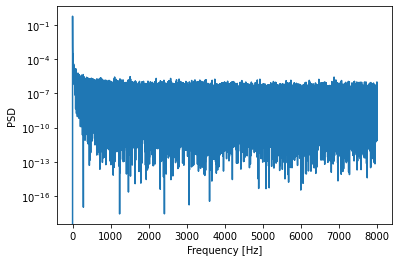

In [29]:
f, Pxx_den = periodogram(data_3, samplerate_3)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([1e-7, 1e2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD')
plt.show()

### Welsh method

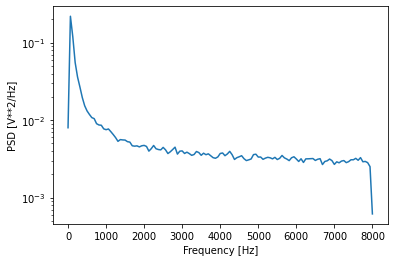

In [31]:
f, Pxx_den = welch(data_3, samplerate_3)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([0.5e-3, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

### Color identification

In [ ]:
#Code

# 2. Image noising and denoising

In [70]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np
import cv2 #Read images and do operations
import numpy.random


from scipy.io import wavfile #Read wavfiles
from scipy.signal import periodogram,welch #Get periodograms
from scipy.fft import fft, fft2,ifft,ifft2, fftfreq #Fourier transform

In [81]:
img = cv2.imread('barbara.jpg',0) #Reading
height,width = img.shape #Getting essential features of image

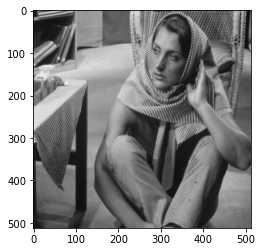

In [93]:
plt.imshow(img,cmap='gray')

In [97]:

mean = 0
std = 40
noise = numpy.random.normal(mean, std, size=img.shape)

img_noise = img + noise

In [133]:

std = 0.5
noise = numpy.random.normal(0, 1, size=img.shape)

img_noise = img + std*noise

Text(0.5, 1.0, 'SNR 26.34329605837734')

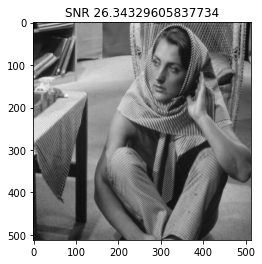

In [134]:
plt.imshow(img_noise,cmap='gray')
plt.title(f'SNR {snr(img,img_noise)}')

In [135]:
def second_norm(x):
    x = np.power(x, 2)
    x = x.sum()
    x = np.sqrt(x)
    return x

def snr(x, y):
    
    return 20*np.log10((second_norm(x))/(second_norm(x-y)))

def snr1(a, axis=0, ddof=0):
    a = np.asanyarray(a)
    m = a.mean(axis)
    sd = a.std(axis=axis, ddof=ddof)
    return 20*np.log10(abs(np.where(sd == 0, 0, m/sd)))

snr(img,img_noise)

26.34329605837734

In [136]:
P = 1/(img_noise.shape[0]*img_noise.shape[1]) * np.power(np.abs(fft2(img_noise)), 2)

In [137]:
h_w = np.abs(ifft2( P / ( P + np.power(std, 2) ) ))

In [138]:
res = np.abs(ifft2(fft2(img_noise) *fft2(h_w)))

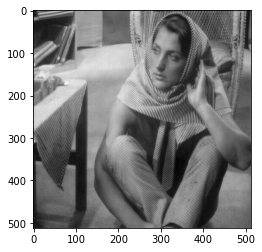

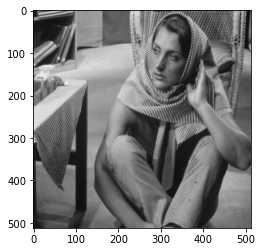

In [139]:
plt.imshow(res,cmap='gray')
plt.show()

plt.imshow(img,cmap='gray')
plt.show()

# 3. Music noising and denoising

In [34]:
samplerate_1, data_1 = wavfile.read("noise1.wav") #Read the file
samplerate_2, data_2 = wavfile.read("noise2.wav") #Read the file
samplerate_3, data_3 = wavfile.read("noise3.wav") #Read the file
samplerate_music, data_music = wavfile.read("music.wav") #Read the file

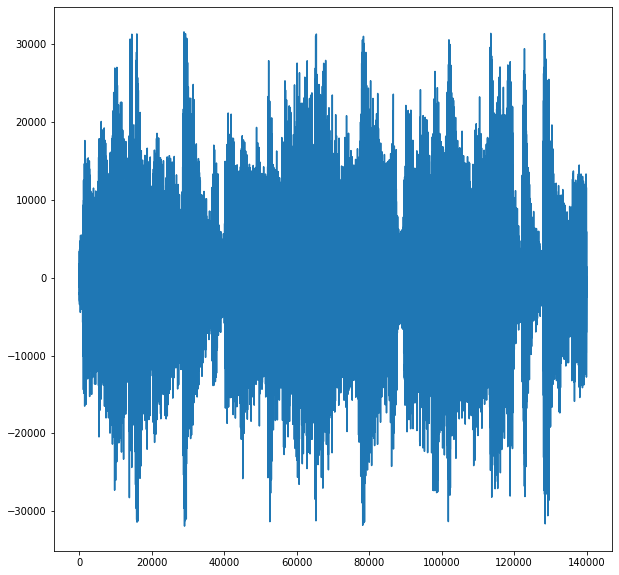

In [35]:
plt.figure(figsize=(10,10))
plt.plot(data_music)

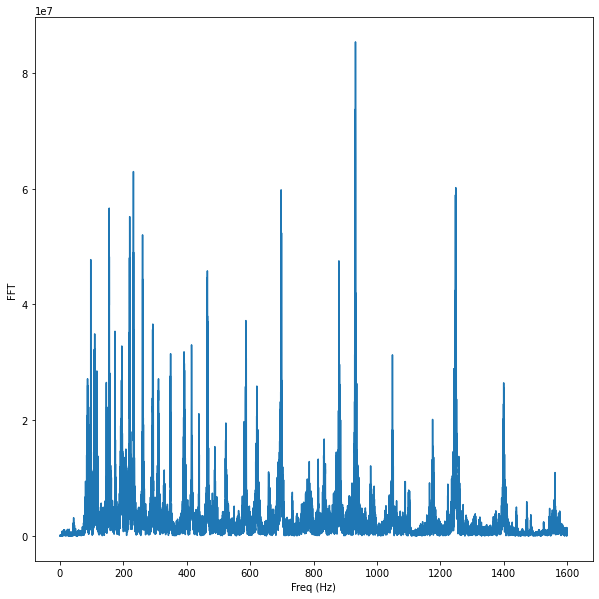

In [42]:
N = data_music.shape[0]
# sample spacing
T = 1.0 / samplerate_music
#Transform
yf = fft(data_music)
xf= fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

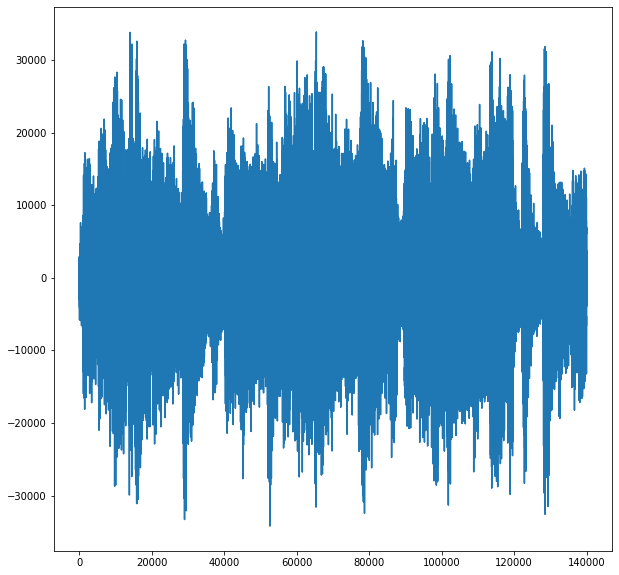

In [43]:
noisy_data_music=data_music+0.1*(data_1+data_2+data_3)
plt.figure(figsize=(10,10))
plt.plot(noisy_data_music)

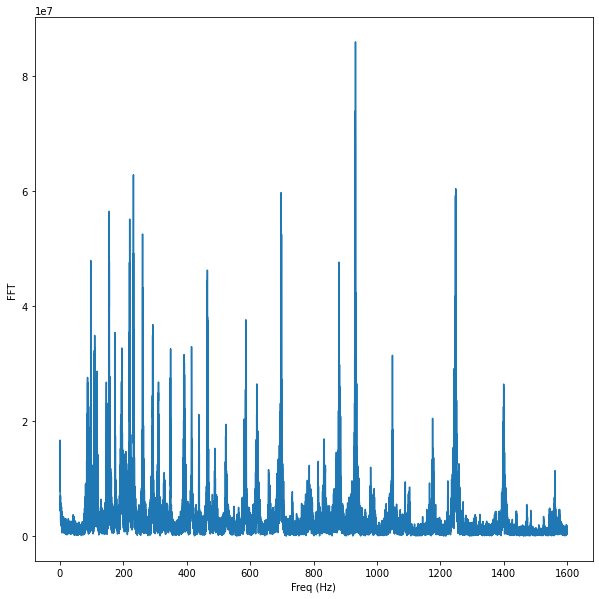

In [44]:
N = noisy_data_music.shape[0]
# sample spacing
T = 1.0 / samplerate_music
#Transform
yf = fft(noisy_data_music)
xf= fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

# References
https://www.youtube.com/watch?v=7STeeVnfYFM